In [1]:
from google.colab import files
uploaded = files.upload()

Saving Customer_Churn_Data_Large.xlsx to Customer_Churn_Data_Large (2).xlsx


## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Check available sheets**

In [3]:
file_path = "Customer_Churn_Data_Large.xlsx"

xls = pd.ExcelFile(file_path)
xls.sheet_names

['Customer_Demographics',
 'Transaction_History',
 'Customer_Service',
 'Online_Activity',
 'Churn_Status']

## **Load All Sheets**

In [4]:
demographics = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transactions = pd.read_excel(file_path, sheet_name='Transaction_History')
service = pd.read_excel(file_path, sheet_name='Customer_Service')
online = pd.read_excel(file_path, sheet_name='Online_Activity')
churn = pd.read_excel(file_path, sheet_name='Churn_Status')

## **Quick Shape Check**

In [5]:
print("Demographics:", demographics.shape)
print("Transactions:", transactions.shape)
print("Service:", service.shape)
print("Online Activity:", online.shape)
print("Churn:", churn.shape)

Demographics: (1000, 5)
Transactions: (5054, 5)
Service: (1002, 5)
Online Activity: (1000, 4)
Churn: (1000, 2)


In [6]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [7]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [8]:
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [9]:
online.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [10]:
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


## **Check unique counts**

In [11]:
print("Demographics unique IDs:", demographics['CustomerID'].nunique())
print("Online unique IDs:", online['CustomerID'].nunique())
print("Churn unique IDs:", churn['CustomerID'].nunique())

Demographics unique IDs: 1000
Online unique IDs: 1000
Churn unique IDs: 1000


In [12]:
service['CustomerID'].nunique()

668

In [13]:
transactions['CustomerID'].nunique()

1000

## **Aggregate Transactions**

In [14]:
transaction_summary = transactions.groupby('CustomerID').agg(
    Total_Transactions=('CustomerID', 'count'),
    Total_Amount_Spent=('AmountSpent', 'sum'),
    Avg_Amount_Spent=('AmountSpent', 'mean')
).reset_index()

transaction_summary.head()

,CustomerID,Total_Transactions,Total_Amount_Spent,Avg_Amount_Spent
0,1,1,416.50,416.50000
1,2,7,1547.42,221.06000
2,3,6,1702.98,283.83000
3,4,5,917.29,183.45800
4,5,8,2001.49,250.18625


In [15]:
transaction_summary.shape

(1000, 4)

## **Aggregate Customer Service Data**

In [16]:
service['Complaint_Flag'] = service['InteractionType'].apply(lambda x: 1 if x == 'Complaint' else 0)
service['Unresolved_Flag'] = service['ResolutionStatus'].apply(lambda x: 1 if x == 'Unresolved' else 0)

service_summary = service.groupby('CustomerID').agg(
    Total_Service_Interactions=('InteractionID', 'count'),
    Total_Complaints=('Complaint_Flag', 'sum'),
    Total_Unresolved=('Unresolved_Flag', 'sum')
).reset_index()

In [17]:
service['InteractionType'].value_counts()

,count
InteractionType,
Feedback,360
Complaint,335
Inquiry,307


## **Merge Everything**

In [18]:
# Start with demographics
df_master = demographics.copy()

# Merging online activity
df_master = df_master.merge(online, on='CustomerID', how='left')

# Merging transaction summary
df_master = df_master.merge(transaction_summary, on='CustomerID', how='left')

# Merging service summary
df_master = df_master.merge(service_summary, on='CustomerID', how='left')

# Merging churn
df_master = df_master.merge(churn, on='CustomerID', how='left')

df_master.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,Total_Transactions,Total_Amount_Spent,Avg_Amount_Spent,Total_Service_Interactions,Total_Complaints,Total_Unresolved,ChurnStatus
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,1,416.50,416.50000,1.0,0.0,0.0,0
1,2,65,M,Married,Low,2023-12-05,5,Website,7,1547.42,221.06000,1.0,0.0,0.0,1
2,3,18,M,Single,Low,2023-11-15,3,Website,6,1702.98,283.83000,1.0,0.0,0.0,0
3,4,21,M,Widowed,Low,2023-08-25,2,Website,5,917.29,183.45800,2.0,0.0,1.0,0
4,5,21,M,Divorced,Medium,2023-10-27,41,Website,8,2001.49,250.18625,NaN,NaN,NaN,0


In [19]:
df_master.shape

(1000, 15)

In [20]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CustomerID                  1000 non-null   int64         
 1   Age                         1000 non-null   int64         
 2   Gender                      1000 non-null   object        
 3   MaritalStatus               1000 non-null   object        
 4   IncomeLevel                 1000 non-null   object        
 5   LastLoginDate               1000 non-null   datetime64[ns]
 6   LoginFrequency              1000 non-null   int64         
 7   ServiceUsage                1000 non-null   object        
 8   Total_Transactions          1000 non-null   int64         
 9   Total_Amount_Spent          1000 non-null   float64       
 10  Avg_Amount_Spent            1000 non-null   float64       
 11  Total_Service_Interactions  668 non-null    float64      

In [21]:
df_master.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
LastLoginDate,0
LoginFrequency,0
ServiceUsage,0
Total_Transactions,0
Total_Amount_Spent,0


In [22]:
df_master[['Total_Service_Interactions',
           'Total_Complaints',
           'Total_Unresolved']] = df_master[['Total_Service_Interactions',
                                             'Total_Complaints',
                                             'Total_Unresolved']].fillna(0)

In [23]:
df_master[['Total_Service_Interactions', 'Total_Complaints']].isnull().sum()

,0
Total_Service_Interactions,0
Total_Complaints,0


In [24]:
df_master.columns

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'LastLoginDate', 'LoginFrequency', 'ServiceUsage', 'Total_Transactions',
       'Total_Amount_Spent', 'Avg_Amount_Spent', 'Total_Service_Interactions',
       'Total_Complaints', 'Total_Unresolved', 'ChurnStatus'],
      dtype='object')

## **Final Null Check**

In [25]:
df_master.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
LastLoginDate,0
LoginFrequency,0
ServiceUsage,0
Total_Transactions,0
Total_Amount_Spent,0


## **Target Distribution**

In [26]:
df_master['ChurnStatus'].value_counts()

,count
ChurnStatus,
0,796
1,204


In [27]:
df_master['ChurnStatus'].value_counts(normalize=True) * 100

,proportion
ChurnStatus,
0,79.6
1,20.4


/tmp/ipython-input-103732862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


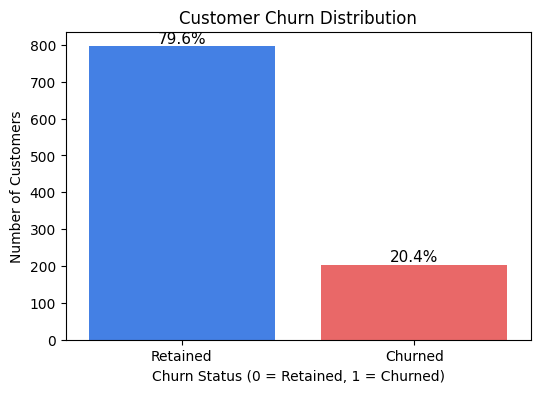

In [28]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df_master,
    x='ChurnStatus',
    palette=["#2979FF", "#FF5252"]
)

total = len(df_master)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Retained", "Churned"])
plt.show()

## **Numerical Summary**

In [29]:
df_master.describe()

,CustomerID,Age,LastLoginDate,LoginFrequency,Total_Transactions,Total_Amount_Spent,Avg_Amount_Spent,Total_Service_Interactions,Total_Complaints,Total_Unresolved,ChurnStatus
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,2023-07-05 21:28:48,25.912000,5.054000,1267.074950,248.806511,1.002000,0.335000,0.479000,0.204000
min,1.000000,18.000000,2023-01-01 00:00:00,1.000000,1.000000,9.800000,9.800000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,30.000000,2023-04-08 00:00:00,13.750000,3.000000,626.685000,203.734167,0.000000,0.000000,0.000000,0.000000
50%,500.500000,43.000000,2023-07-10 12:00:00,27.000000,5.000000,1232.880000,250.121458,1.000000,0.000000,0.000000,0.000000
75%,750.250000,56.000000,2023-10-01 06:00:00,38.000000,7.000000,1791.902500,295.023854,2.000000,1.000000,1.000000,0.000000
max,1000.000000,69.000000,2023-12-31 00:00:00,49.000000,9.000000,3386.040000,496.990000,2.000000,2.000000,2.000000,1.000000
std,288.819436,15.242311,NaN,14.055953,2.603433,738.590013,79.372766,0.816494,0.546877,0.621245,0.403171


## **Correlation with Churn**

In [30]:
df_master.corr(numeric_only=True)['ChurnStatus'].sort_values(ascending=False)

,ChurnStatus
ChurnStatus,1.000000
Avg_Amount_Spent,0.044811
Age,0.029407
Total_Complaints,0.016616
Total_Unresolved,0.005132
Total_Service_Interactions,0.004841
Total_Amount_Spent,0.001324
Total_Transactions,-0.008598
CustomerID,-0.011528
LoginFrequency,-0.081615


## **Login Frequency vs Churn**

In [31]:
sns.set_style("whitegrid")
sns.set_palette(["#2979FF", "#FF5252"])
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

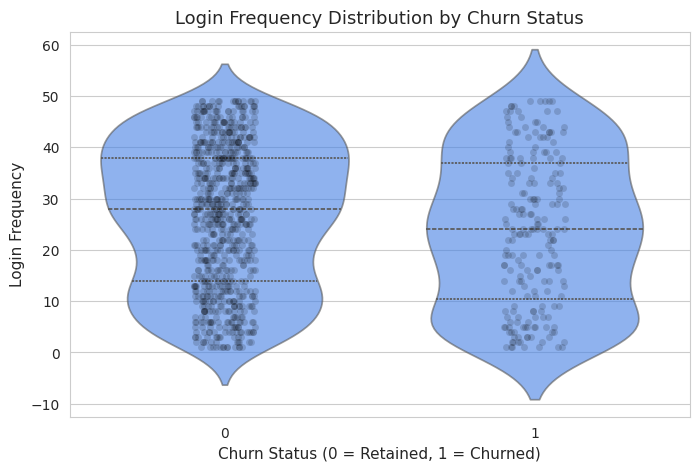

In [32]:
plt.figure()
sns.violinplot(x='ChurnStatus', y='LoginFrequency',
               data=df_master, inner='quartile', alpha=0.6)

sns.stripplot(x='ChurnStatus', y='LoginFrequency',
              data=df_master, color='black', alpha=0.15)

plt.title("Login Frequency Distribution by Churn Status")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Login Frequency")
plt.show()

## **Days Since Last Login vs Churn**

In [33]:
df_master['LastLoginDate'] = pd.to_datetime(df_master['LastLoginDate'])

# Create Days Since Last Login
latest_date = df_master['LastLoginDate'].max()

df_master['Days_Since_Last_Login'] = (latest_date - df_master['LastLoginDate']).dt.days

df_master[['LastLoginDate', 'Days_Since_Last_Login']].head()

,LastLoginDate,Days_Since_Last_Login
0,2023-10-21,71
1,2023-12-05,26
2,2023-11-15,46
3,2023-08-25,128
4,2023-10-27,65


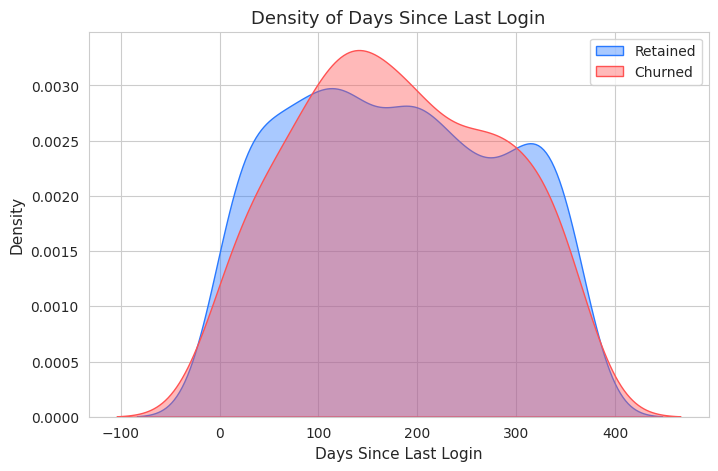

In [34]:
plt.figure()

sns.kdeplot(data=df_master[df_master['ChurnStatus']==0],
            x='Days_Since_Last_Login',
            fill=True, alpha=0.4, label='Retained')

sns.kdeplot(data=df_master[df_master['ChurnStatus']==1],
            x='Days_Since_Last_Login',
            fill=True, alpha=0.4, label='Churned')

plt.title("Density of Days Since Last Login")
plt.xlabel("Days Since Last Login")
plt.legend()
plt.show()

## **Complaints vs Churn**

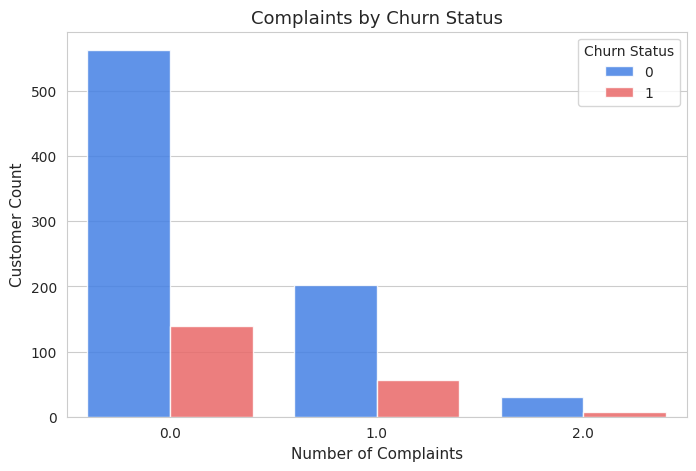

In [35]:
plt.figure()

complaint_plot = sns.countplot(
    data=df_master,
    x='Total_Complaints',
    hue='ChurnStatus',
    alpha=0.85
)

plt.title("Complaints by Churn Status")
plt.xlabel("Number of Complaints")
plt.ylabel("Customer Count")
plt.legend(title="Churn Status")
plt.show()

## **Income Level vs Churn (Categorical EDA)**

In [36]:
pd.crosstab(df_master['IncomeLevel'],
            df_master['ChurnStatus'],
            normalize='index') * 100

ChurnStatus,0,1
IncomeLevel,,
High,80.802292,19.197708
Low,77.846154,22.153846
Medium,80.061350,19.938650


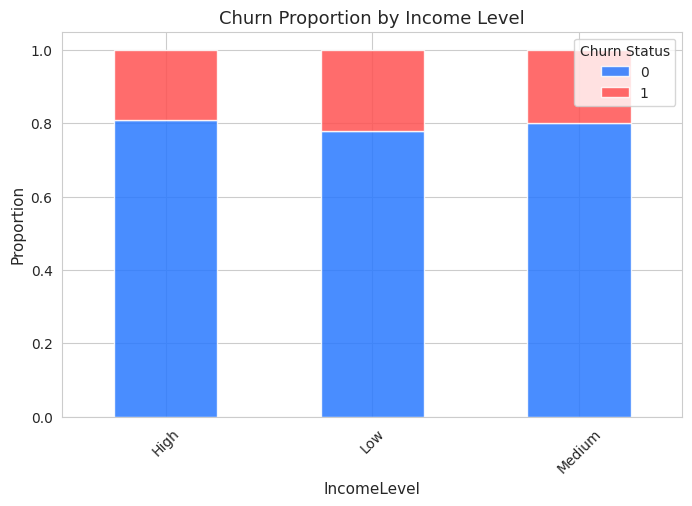

In [37]:
income_churn = pd.crosstab(df_master['IncomeLevel'],
                           df_master['ChurnStatus'],
                           normalize='index')

income_churn.plot(kind='bar',
                  stacked=True,
                  alpha=0.85)

plt.title("Churn Proportion by Income Level")
plt.ylabel("Proportion")
plt.legend(title="Churn Status")
plt.xticks(rotation=45)
plt.show()

## **Gender vs Churn**

In [38]:
pd.crosstab(df_master['Gender'],
            df_master['ChurnStatus'],
            normalize='index') * 100

ChurnStatus,0,1
Gender,,
F,80.311891,19.688109
M,78.850103,21.149897


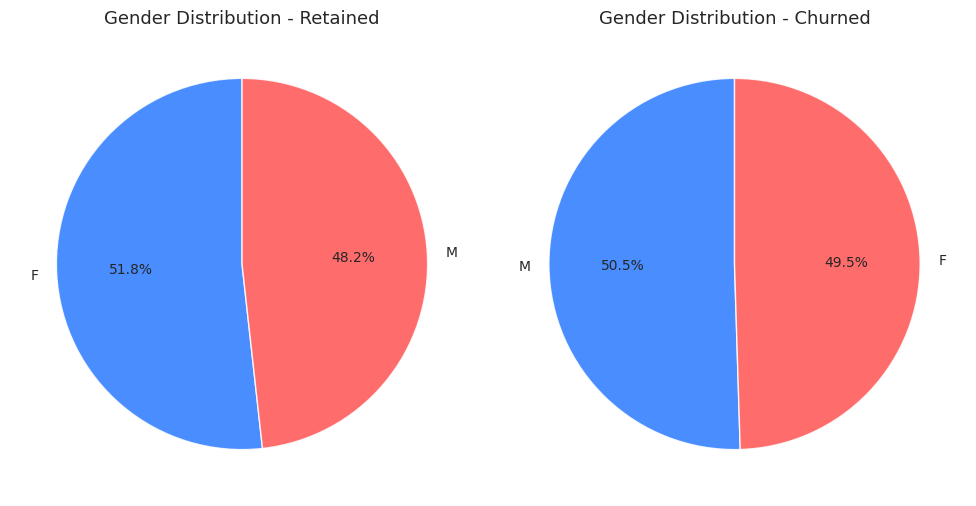

In [39]:
# Split data
retained = df_master[df_master['ChurnStatus'] == 0]['Gender'].value_counts()
churned = df_master[df_master['ChurnStatus'] == 1]['Gender'].value_counts()

colors = ["#2979FF", "#FF5252"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Retained pie
axes[0].pie(retained,
            labels=retained.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'alpha': 0.85})

axes[0].set_title("Gender Distribution - Retained")

# Churned pie
axes[1].pie(churned,
            labels=churned.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'alpha': 0.85})

axes[1].set_title("Gender Distribution - Churned")

plt.tight_layout()
plt.show()

In [40]:
pd.crosstab(df_master['MaritalStatus'],
            df_master['ChurnStatus'],
            normalize='index') * 100

ChurnStatus,0,1
MaritalStatus,,
Divorced,81.451613,18.548387
Married,77.011494,22.988506
Single,79.534884,20.465116
Widowed,80.434783,19.565217


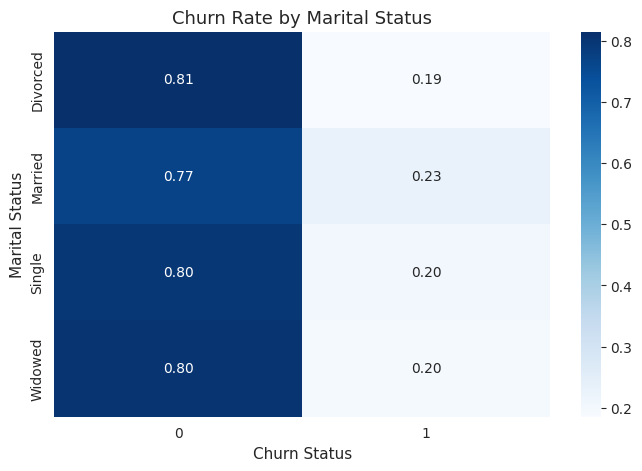

In [41]:
marital_churn = pd.crosstab(df_master['MaritalStatus'],
                            df_master['ChurnStatus'],
                            normalize='index')

plt.figure()

sns.heatmap(marital_churn,
            annot=True,
            cmap='Blues',
            fmt=".2f")

plt.title("Churn Rate by Marital Status")
plt.xlabel("Churn Status")
plt.ylabel("Marital Status")
plt.show()

# Executive Summary – Customer Churn Exploratory Analysis

## Overview

This analysis examined customer demographic, behavioral, transactional, and service interaction data to identify early indicators of churn. The dataset consists of 1,000 customers, with a churn rate of **20.4%**, reflecting a realistic and moderately imbalanced scenario.

---

## Key Findings

### 1️. Customer Engagement is the Strongest Signal

- **Login Frequency** shows the strongest inverse relationship with churn.
- Customers with lower login activity are slightly more likely to churn.
- Increased **Days Since Last Login** suggests disengagement behavior.

**Business Insight:**  
Customer inactivity is an early warning signal. Monitoring digital engagement can enable proactive retention efforts.

---

### 2️. Complaints and Service Interactions Have Weak Standalone Impact

- Complaint counts and unresolved issues show minimal separation between churned and retained customers.
- Service interactions alone do not strongly explain churn.

**Business Insight:**  
Customer dissatisfaction may contribute to churn, but it likely interacts with other behavioral factors rather than acting independently.

---

### 3️. Demographics Are Not Major Drivers

- Gender distribution is nearly identical between churned and retained groups.
- Income levels and marital status show minimal differences in churn proportion.
- Age differences are small.

**Business Insight:**  
Churn appears behavior-driven rather than demographic-driven.

---

### 4️. Spending Behavior Shows Subtle Patterns

- Average spending shows slight variation, but no strong linear relationship.
- Transaction frequency does not strongly separate churners from retained customers.

**Business Insight:**  
High or low spending alone does not determine churn risk. Engagement patterns matter more than raw financial metrics.

---

## Strategic Interpretation

The analysis indicates that churn in this dataset is subtle and likely driven by **multivariate interactions**, rather than a single dominant feature.

Behavioral engagement metrics (particularly digital activity) provide the strongest early indicators of churn risk.

This supports the need for a predictive machine learning model to capture complex relationships between variables.

---

## Next Steps

- Develop a classification model to predict churn probability.
- Evaluate performance using Recall and ROC-AUC.
- Identify high-risk customer segments for targeted retention strategies.